In [13]:
#IMPORT NECESSARY LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [14]:
# Load the dataset

data=pd.read_csv("C:/Users/naure/Downloads/Crop_recommendation.csv")

In [15]:
#.info Function is used to give necesarry information about dataset

data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


In [16]:
data.isnull().sum()

N              0
P              0
K              0
temperature    0
humidity       0
ph             0
rainfall       0
label          0
dtype: int64

In [17]:
data.shape

(2200, 8)

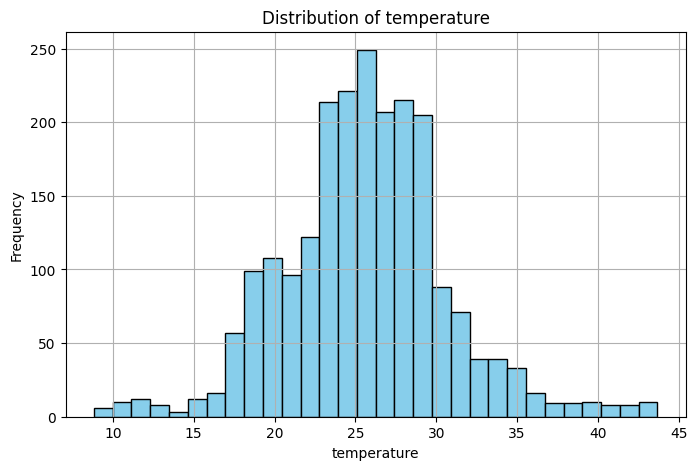

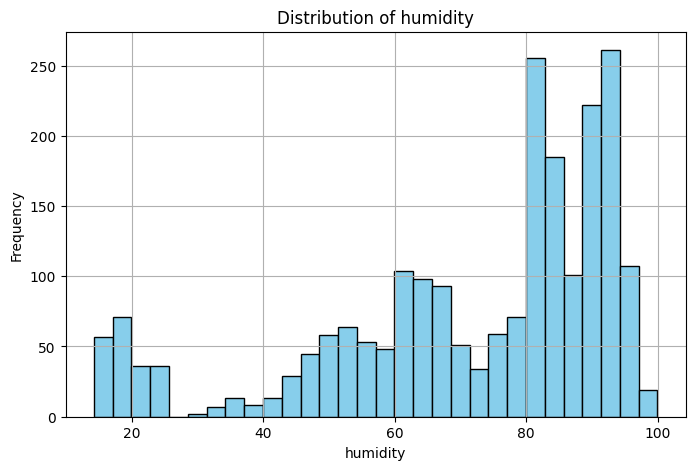

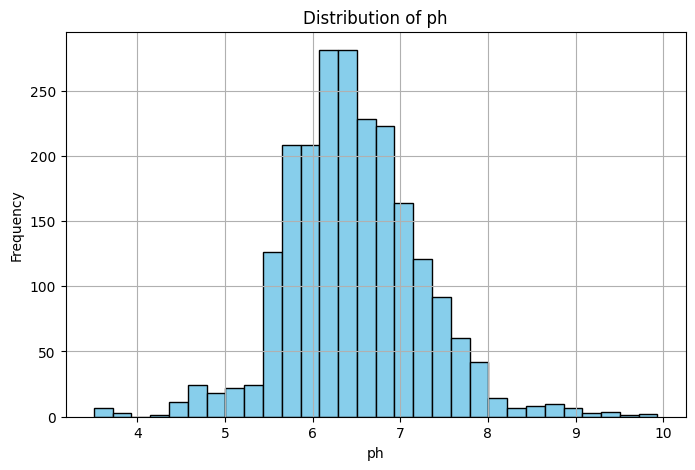

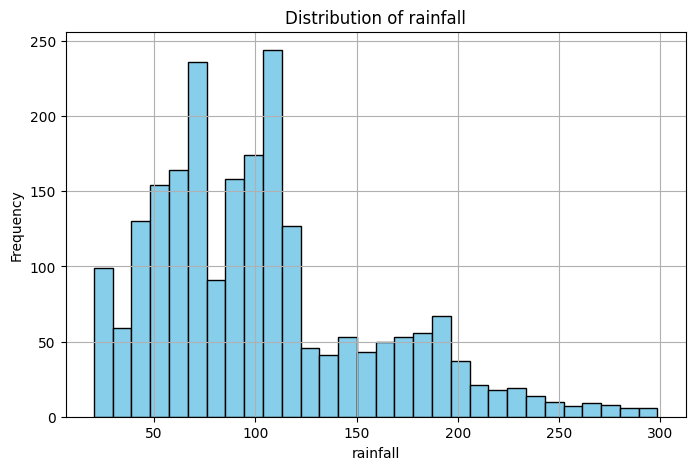

In [20]:
features = ['temperature', 'humidity', 'ph', 'rainfall']
for feature in features:
    plt.figure(figsize=(8, 5))
    plt.hist(data[feature], bins=30, color='skyblue', edgecolor='black')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

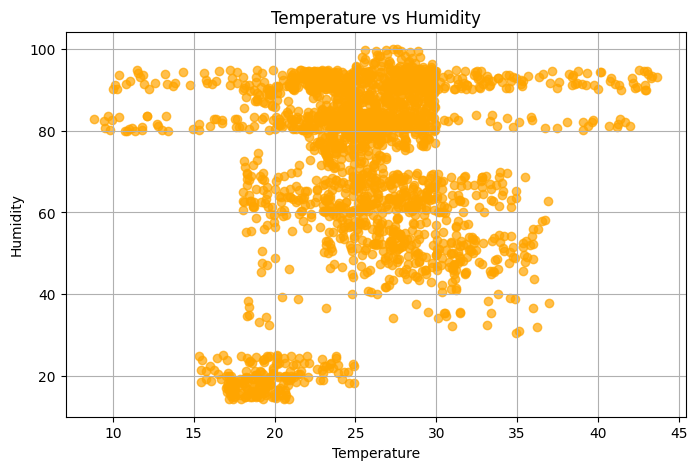

In [21]:
# Scatter plot between temperature and humidity
plt.figure(figsize=(8, 5))
plt.scatter(data['temperature'], data['humidity'], color='orange', alpha=0.7)
plt.title('Temperature vs Humidity')
plt.xlabel('Temperature')
plt.ylabel('Humidity')
plt.grid(True)
plt.show()

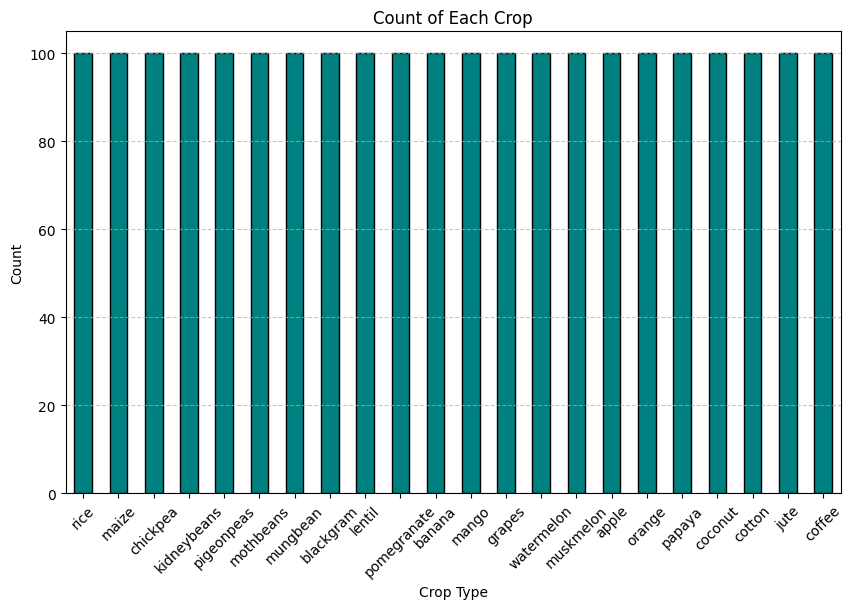

In [22]:
# Bar plot of crop labels
plt.figure(figsize=(10, 6))
data['label'].value_counts().plot(kind='bar', color='teal', edgecolor='black')
plt.title('Count of Each Crop')
plt.xlabel('Crop Type')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.show()

In [25]:
#.head is used to give 5 starting rows and all columns of dataset

data.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [26]:
# Features (independant variables) are seperated from Target Variable (dependant variable)

X = data[['N', 'P', 'P', 'temperature', 'humidity','ph','rainfall']]  # Input features
y = data['label']

In [27]:
#.describe is used to print the mean,max,min,count,etc values of dataset

data.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [28]:
#The function data.columns is used to print all columns of dataset

print("Columns in dataset : ",data.columns)

Columns in dataset :  Index(['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall', 'label'], dtype='object')


In [29]:
#THIS SPLITS THE DATA INTO TRAINING AND TESTING SETS
#WE WILL USE 70% OF DATA FOR TRAINING AND 30% FOR TESTING

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [30]:
# A RANDOM FOREST CLASSIFIER IS INITIALIZED WITH 100 DECISION TREES FOR ENSEMBLE LEARNING

model = RandomForestClassifier(n_estimators=100, random_state=42)

In [31]:
#MODEL IS TRAINED ON TRAINING SET

model.fit(X_train, y_train)
print(" trained")

 trained


In [32]:
#PREDICTION IS MADE ON TESTING SET

y_pred = model.predict(X_test)

In [33]:
# ACCURACY IS CALCULATED TO EVALUATE PERFORMANCE

accuracy = accuracy_score(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Model Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:\n")
print(classification_rep)

Model Accuracy: 98.33%

Classification Report:

              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        34
      banana       1.00      1.00      1.00        26
   blackgram       1.00      1.00      1.00        26
    chickpea       1.00      1.00      1.00        34
     coconut       1.00      1.00      1.00        33
      coffee       0.97      1.00      0.98        30
      cotton       1.00      1.00      1.00        28
      grapes       1.00      1.00      1.00        23
        jute       0.85      0.97      0.90        34
 kidneybeans       1.00      1.00      1.00        36
      lentil       1.00      1.00      1.00        22
       maize       1.00      1.00      1.00        26
       mango       1.00      1.00      1.00        32
   mothbeans       1.00      1.00      1.00        34
    mungbean       1.00      1.00      1.00        30
   muskmelon       1.00      1.00      1.00        24
      orange       0.92      0.92

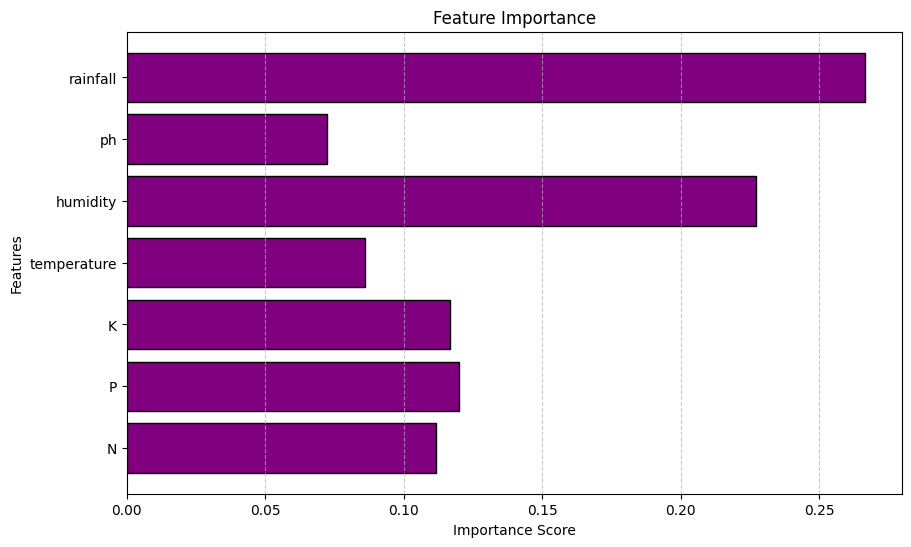

In [34]:
# Assuming your trained Random Forest model is `model`
feature_importance = model.feature_importances_
features = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

plt.figure(figsize=(10, 6))
plt.barh(features, feature_importance, color='purple', edgecolor='black')
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()